# ARIS Monitor — Addestramento e Confronto Modelli
## Isolation Forest vs Autoencoder su 16 runnable

Pipeline:
1. **Preprocessing** — caricamento, encoding, scaling
2. **Isolation Forest** — addestramento per-runnable
3. **Autoencoder** — addestramento per-runnable
4. **Validazione retrospettiva** — i 5 crash noti di arcm_s
5. **Confronto** — quale modello rileva meglio e prima?
6. **Esportazione** — salvataggio modelli e score

> Eseguire cella per cella. Le celle con `# ⏱` possono richiedere qualche secondo.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Configurazione ──
CSV_PATH = "/home/vicacrit/Azienda/Use_Case_2/features_all.csv"
RANDOM_STATE = 42
IF_CONTAMINATION = 0.03       # 3% anomalie attese (conservativo)
IF_N_ESTIMATORS = 200         # alberi nell'Isolation Forest
AE_EPOCHS = 50                # epoche Autoencoder
AE_ENCODING_DIM = 6           # dimensione bottleneck
AE_THRESHOLD_PERCENTILE = 97  # soglia anomalia (percentile errore ricostruzione)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("Setup completo.")
print(f"IF: contamination={IF_CONTAMINATION}, n_estimators={IF_N_ESTIMATORS}")
print(f"AE: epochs={AE_EPOCHS}, encoding_dim={AE_ENCODING_DIM}, threshold_pct={AE_THRESHOLD_PERCENTILE}")

Setup completo.
IF: contamination=0.03, n_estimators=200
AE: epochs=50, encoding_dim=6, threshold_pct=97


---
## 1. Preprocessing

### Feature numeriche usate per il modello
Escludiamo le feature infrastrutturali (tutte -1) e i metadati (runnable, timestamp).
Codifichiamo `current_state` come rischio numerico.

In [4]:
df = pd.read_csv(CSV_PATH)
df['ts'] = pd.to_datetime(df['window_end'])
print(f"Dataset: {df.shape[0]} righe × {df.shape[1]} colonne")
print(f"Runnable: {sorted(df['runnable'].unique())}")

# ── Encoding dello stato come rischio ──
STATE_RISK = {
    'STARTED': 0,
    'UNKNOWN': 1,      # non sappiamo → leggero rischio
    'STARTING': 3,     # in avvio → instabile
    'STOPPING': 4,     # in arresto → instabile
    'STOPPED': 5,      # fermo → problema
    'FAILED': 8,       # fallito → grave
    'DEACTIVATED': 2,  # disattivato volontariamente → basso rischio
    'INOPERATIVE': 10, # inoperativo → critico
}
df['state_risk'] = df['current_state'].map(STATE_RISK).fillna(1)

# ── Feature numeriche per il modello ──
FEATURE_COLS = [
    'error_count_5m', 'error_count_1h', 'fatal_count_1h', 'warn_count_1h',
    'distinct_errors_5m', 'error_rate_delta', 'has_stack_trace_5m',
    'state_transitions_1h', 'restarts_24h',
    'pool_exhaustion_count_5m', 'bus_error_count_5m', 'zkc_error_count_5m',
    'state_risk',
]

print(f"\nFeature per il modello ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  - {f}")

# ── Verifica: nessun NaN ──
print(f"\nNaN per feature:")
for f in FEATURE_COLS:
    n = df[f].isna().sum()
    if n > 0:
        print(f"  {f}: {n} NaN!")
    else:
        print(f"  {f}: OK")

Dataset: 89682 righe × 28 colonne
Runnable: ['abs_s', 'adsadmin_s', 'agent', 'apg_s', 'arcm_s', 'cdf_s', 'ces_s', 'cloudsearch_s', 'copernicus_s', 'dashboarding_s', 'ecp_s', 'elastic_s', 'octopus_s', 'simulation_s', 'umcadmin_s', 'zoo_s']

Feature per il modello (13):
  - error_count_5m
  - error_count_1h
  - fatal_count_1h
  - warn_count_1h
  - distinct_errors_5m
  - error_rate_delta
  - has_stack_trace_5m
  - state_transitions_1h
  - restarts_24h
  - pool_exhaustion_count_5m
  - bus_error_count_5m
  - zkc_error_count_5m
  - state_risk

NaN per feature:
  error_count_5m: OK
  error_count_1h: OK
  fatal_count_1h: OK
  warn_count_1h: OK
  distinct_errors_5m: OK
  error_rate_delta: OK
  has_stack_trace_5m: OK
  state_transitions_1h: OK
  restarts_24h: OK
  pool_exhaustion_count_5m: OK
  bus_error_count_5m: OK
  zkc_error_count_5m: OK
  state_risk: OK


---
## 2. Isolation Forest — Addestramento per-runnable

Addestriamo un IF separato per ogni runnable. Ogni modello impara
il "comportamento normale" del proprio runnable e segnala le anomalie.

In [5]:
# ⏱ Addestramento IF per tutti i runnable

if_models = {}     # runnable → modello IF
if_scalers = {}    # runnable → scaler
if_scores = {}     # runnable → array di anomaly scores
if_labels = {}     # runnable → array di labels (-1=anomaly, 1=normal)

print("Addestramento Isolation Forest per runnable:")
print("=" * 70)

for runnable in sorted(df['runnable'].unique()):
    sub = df[df['runnable'] == runnable].copy()
    X = sub[FEATURE_COLS].values
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Addestramento
    iso = IsolationForest(
        contamination=IF_CONTAMINATION,
        n_estimators=IF_N_ESTIMATORS,
        max_samples='auto',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iso.fit(X_scaled)
    
    # Score e labels
    raw_scores = iso.decision_function(X_scaled)  # più basso = più anomalo
    labels = iso.predict(X_scaled)                # -1 = anomaly, 1 = normal
    
    # Normalizzazione score 0-100 (percentile-based)
    from scipy.stats import percentileofscore
    norm_scores = np.array([100 - percentileofscore(raw_scores, s) for s in raw_scores])
    
    if_models[runnable] = iso
    if_scalers[runnable] = scaler
    if_scores[runnable] = norm_scores
    if_labels[runnable] = labels
    
    n_anomalies = (labels == -1).sum()
    pct = n_anomalies / len(labels) * 100
    
    # Statistiche score
    print(f"  {runnable:25s}: {len(sub):>6d} vettori, "
          f"{n_anomalies:>4d} anomalie ({pct:.1f}%), "
          f"score range [{norm_scores.min():.1f}, {norm_scores.max():.1f}]")

    # Salva scores nel dataframe
    df.loc[df['runnable'] == runnable, 'if_score'] = norm_scores
    df.loc[df['runnable'] == runnable, 'if_label'] = labels

print(f"\nTotale anomalie IF: {(df['if_label'] == -1).sum()} / {len(df)} "
      f"({(df['if_label'] == -1).sum()/len(df)*100:.1f}%)")

Addestramento Isolation Forest per runnable:
  abs_s                    :   4693 vettori,  141 anomalie (3.0%), score range [19.9, 100.0]
  adsadmin_s               :   3742 vettori,  107 anomalie (2.9%), score range [32.6, 100.0]
  agent                    :  29503 vettori,  875 anomalie (3.0%), score range [19.4, 100.0]
  apg_s                    :   3641 vettori,  109 anomalie (3.0%), score range [33.1, 100.0]
  arcm_s                   :   7735 vettori,  231 anomalie (3.0%), score range [13.8, 100.0]
  cdf_s                    :   3417 vettori,   88 anomalie (2.6%), score range [35.4, 100.0]
  ces_s                    :   3421 vettori,   93 anomalie (2.7%), score range [35.3, 100.0]
  cloudsearch_s            :   3372 vettori,    6 anomalie (0.2%), score range [36.0, 100.0]
  copernicus_s             :   4406 vettori,  128 anomalie (2.9%), score range [24.5, 100.0]
  dashboarding_s           :   3702 vettori,  109 anomalie (2.9%), score range [32.4, 100.0]
  ecp_s                  

---
## 3. Autoencoder — Addestramento per-runnable

L'Autoencoder impara a ricostruire i vettori "normali". 
I vettori anomali avranno un errore di ricostruzione alto.

In [6]:
# ⏱ Autoencoder — potrebbe richiedere 1-2 minuti

try:
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    import tensorflow as tf
    tf.random.set_seed(RANDOM_STATE)
    HAS_TF = True
    print("TensorFlow disponibile — addestramento Autoencoder attivo.")
except ImportError:
    HAS_TF = False
    print("TensorFlow NON disponibile. Installa con: pip install tensorflow")
    print("L'Autoencoder verrà saltato, procederemo solo con Isolation Forest.")

if HAS_TF:
    ae_models = {}
    ae_thresholds = {}
    ae_scores = {}
    ae_labels = {}
    
    print("\nAddestramento Autoencoder per runnable:")
    print("=" * 70)
    
    for runnable in sorted(df['runnable'].unique()):
        sub = df[df['runnable'] == runnable].copy()
        X = sub[FEATURE_COLS].values
        
        # Usa lo stesso scaler dell'IF per coerenza
        X_scaled = if_scalers[runnable].transform(X)
        
        input_dim = X_scaled.shape[1]
        
        # Architettura: input → 10 → 6 → 10 → input
        inp = Input(shape=(input_dim,))
        encoded = Dense(10, activation='relu')(inp)
        encoded = Dropout(0.2)(encoded)
        encoded = Dense(AE_ENCODING_DIM, activation='relu')(encoded)
        decoded = Dense(10, activation='relu')(encoded)
        decoded = Dense(input_dim, activation='linear')(decoded)
        
        autoencoder = Model(inp, decoded)
        autoencoder.compile(optimizer='adam', loss='mse')
        
        # Addestramento (silenzioso)
        autoencoder.fit(
            X_scaled, X_scaled,
            epochs=AE_EPOCHS,
            batch_size=64,
            shuffle=True,
            validation_split=0.1,
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
            verbose=0,
        )
        
        # Errore di ricostruzione per ogni vettore
        X_pred = autoencoder.predict(X_scaled, verbose=0)
        recon_error = np.mean(np.square(X_scaled - X_pred), axis=1)
        
        # Soglia: percentile dell'errore
        threshold = np.percentile(recon_error, AE_THRESHOLD_PERCENTILE)
        
        # Normalizzazione 0-100
        max_err = recon_error.max()
        min_err = recon_error.min()
        if max_err > min_err:
            norm_scores = (recon_error - min_err) / (max_err - min_err) * 100
        else:
            norm_scores = np.zeros_like(recon_error)
        
        # Labels
        labels = np.where(recon_error > threshold, -1, 1)
        
        ae_models[runnable] = autoencoder
        ae_thresholds[runnable] = threshold
        ae_scores[runnable] = norm_scores
        ae_labels[runnable] = labels
        
        n_anomalies = (labels == -1).sum()
        pct = n_anomalies / len(labels) * 100
        
        print(f"  {runnable:25s}: {n_anomalies:>4d} anomalie ({pct:.1f}%), "
              f"threshold={threshold:.4f}, "
              f"recon_err range [{recon_error.min():.4f}, {recon_error.max():.4f}]")
        
        df.loc[df['runnable'] == runnable, 'ae_score'] = norm_scores
        df.loc[df['runnable'] == runnable, 'ae_label'] = labels
    
    print(f"\nTotale anomalie AE: {(df['ae_label'] == -1).sum()} / {len(df)} "
          f"({(df['ae_label'] == -1).sum()/len(df)*100:.1f}%)")

I0000 00:00:1773245710.200996    8947 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773245710.872115    8947 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773245713.467613    8947 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow disponibile — addestramento Autoencoder attivo.

Addestramento Autoencoder per runnable:


E0000 00:00:1773245714.292217    8947 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  abs_s                    :  141 anomalie (3.0%), threshold=0.8548, recon_err range [0.0002, 84.2512]
  adsadmin_s               :  107 anomalie (2.9%), threshold=0.1679, recon_err range [0.0000, 72.6494]
  agent                    :  875 anomalie (3.0%), threshold=0.0434, recon_err range [0.0001, 886.7121]
  apg_s                    :  109 anomalie (3.0%), threshold=0.4106, recon_err range [0.0004, 177.3956]
  arcm_s                   :  233 anomalie (3.0%), threshold=0.3315, recon_err range [0.0001, 10.1736]
  cdf_s                    :   88 anomalie (2.6%), threshold=0.0111, recon_err range [0.0000, 130.5650]
  ces_s                    :  100 anomalie (2.9%), threshold=0.0112, recon_err range [0.0001, 515.0519]
  cloudsearch_s            :    6 anomalie (0.2%), threshold=0.0100, recon_err range [0.0001, 0.6654]
  copernicus_s             :  133 anomalie (3.0%), threshold=0.2933, recon_err range [0.0002, 91.3368]
  dashboarding_s           :   77 anomalie (2.1%), threshold=1.1994, r

---
## 4. Validazione retrospettiva — I 5 crash noti di arcm_s

Questa è la prova del fuoco: il modello rileva i crash noti?
E soprattutto, li rileva **prima** che esplodano?

In [8]:
arcm = df[df['runnable'] == 'arcm_s'].copy()

crash_windows = [
    {
        'name': 'C1: Migration failure restart loop',
        'date': '10 Nov 2025',
        'peak_start': '2025-11-10 09:45',
        'peak_end': '2025-11-10 12:00',
        'pre_start': '2025-11-10 06:00',   # 4 ore prima
        'pre_end': '2025-11-10 09:44',
        'pattern': 'fatal + restart',
    },
    {
        'name': 'C2: Pool exhaustion early warnings',
        'date': '3-4 Dec 2025',
        'peak_start': '2025-12-03 03:00',
        'peak_end': '2025-12-04 06:00',
        'pre_start': '2025-12-02 18:00',
        'pre_end': '2025-12-03 02:59',
        'pattern': 'pool + bus',
    },
    {
        'name': 'C3: Pool exhaustion sustained (6 giorni)',
        'date': '18-23 Dec 2025',
        'peak_start': '2025-12-18 00:00',
        'peak_end': '2025-12-23 23:59',
        'pre_start': '2025-12-17 12:00',
        'pre_end': '2025-12-17 23:59',
        'pattern': 'pool + bus sustained',
    },
    {
        'name': 'C4: Pool exhaustion recurrence',
        'date': '15-16 Gen 2026',
        'peak_start': '2026-01-15 00:00',
        'peak_end': '2026-01-16 23:59',
        'pre_start': '2026-01-14 12:00',
        'pre_end': '2026-01-14 23:59',
        'pattern': 'pool recurrence',
    },
    {
        'name': 'C5: NPE + BulkExport',
        'date': '20 Feb 2026',
        'peak_start': '2026-02-20 14:00',
        'peak_end': '2026-02-20 16:00',
        'pre_start': '2026-02-20 10:00',
        'pre_end': '2026-02-20 13:59',
        'pattern': 'NPE + stack',
    },
]

print("VALIDAZIONE RETROSPETTIVA — arcm_s")
print("=" * 90)

for crash in crash_windows:
    print(f"\n{'─'*90}")
    print(f"  {crash['name']} ({crash['date']})")
    print(f"{'─'*90}")
    
    # Finestra pre-crash
    pre = arcm[(arcm['ts'] >= crash['pre_start']) & (arcm['ts'] <= crash['pre_end'])]
    # Finestra crash
    peak = arcm[(arcm['ts'] >= crash['peak_start']) & (arcm['ts'] <= crash['peak_end'])]
    
    for label, window in [('PRE-CRASH', pre), ('DURANTE', peak)]:
        if len(window) == 0:
            print(f"  {label}: nessun vettore nel periodo")
            continue
            
        # IF
        if_anom = (window['if_label'] == -1).sum()
        if_score_max = window['if_score'].max()
        if_score_mean = window['if_score'].mean()
        
        print(f"  {label} ({len(window)} vettori):")
        print(f"    IF:  {if_anom:>3d} anomalie ({if_anom/len(window)*100:.0f}%), "
              f"score max={if_score_max:.1f}, mean={if_score_mean:.1f}")
        
        # AE (se disponibile)
        if 'ae_label' in window.columns and window['ae_label'].notna().any():
            ae_anom = (window['ae_label'] == -1).sum()
            ae_score_max = window['ae_score'].max()
            ae_score_mean = window['ae_score'].mean()
            print(f"    AE:  {ae_anom:>3d} anomalie ({ae_anom/len(window)*100:.0f}%), "
                  f"score max={ae_score_max:.1f}, mean={ae_score_mean:.1f}")
    
    # Early warning: IF ha rilevato anomalie PRIMA del crash?
    if len(pre) > 0:
        pre_if = pre[pre['if_label'] == -1]
        if len(pre_if) > 0:
            first_alert = pre_if['ts'].min()
            minutes_before = (pd.Timestamp(crash['peak_start']).tz_localize('UTC') - first_alert).total_seconds() / 60
            print(f"  ⚠ IF EARLY WARNING: primo allarme {minutes_before:.0f} min prima del crash")
        else:
            print(f"  ✗ IF: nessun early warning nel pre-crash")
        
        if 'ae_label' in pre.columns and pre['ae_label'].notna().any():
            pre_ae = pre[pre['ae_label'] == -1]
            if len(pre_ae) > 0:
                first_alert = pre_ae['ts'].min()
                minutes_before = (pd.Timestamp(crash['peak_start']).tz_localize('UTC') - first_alert).total_seconds() / 60
                print(f"  ⚠ AE EARLY WARNING: primo allarme {minutes_before:.0f} min prima del crash")
            else:
                print(f"  ✗ AE: nessun early warning nel pre-crash")

VALIDAZIONE RETROSPETTIVA — arcm_s

──────────────────────────────────────────────────────────────────────────────────────────
  C1: Migration failure restart loop (10 Nov 2025)
──────────────────────────────────────────────────────────────────────────────────────────
  PRE-CRASH (4 vettori):
    IF:    0 anomalie (0%), score max=13.8, mean=13.8
    AE:    0 anomalie (0%), score max=0.0, mean=0.0
  DURANTE (27 vettori):
    IF:   18 anomalie (67%), score max=99.7, mean=97.6
    AE:   16 anomalie (59%), score max=100.0, mean=14.4
  ✗ IF: nessun early warning nel pre-crash
  ✗ AE: nessun early warning nel pre-crash

──────────────────────────────────────────────────────────────────────────────────────────
  C2: Pool exhaustion early warnings (3-4 Dec 2025)
──────────────────────────────────────────────────────────────────────────────────────────
  PRE-CRASH (20 vettori):
    IF:    0 anomalie (0%), score max=93.9, mean=31.7
    AE:    0 anomalie (0%), score max=0.2, mean=0.0
  DURANTE (1

### 4.1 Timeline score durante i crash

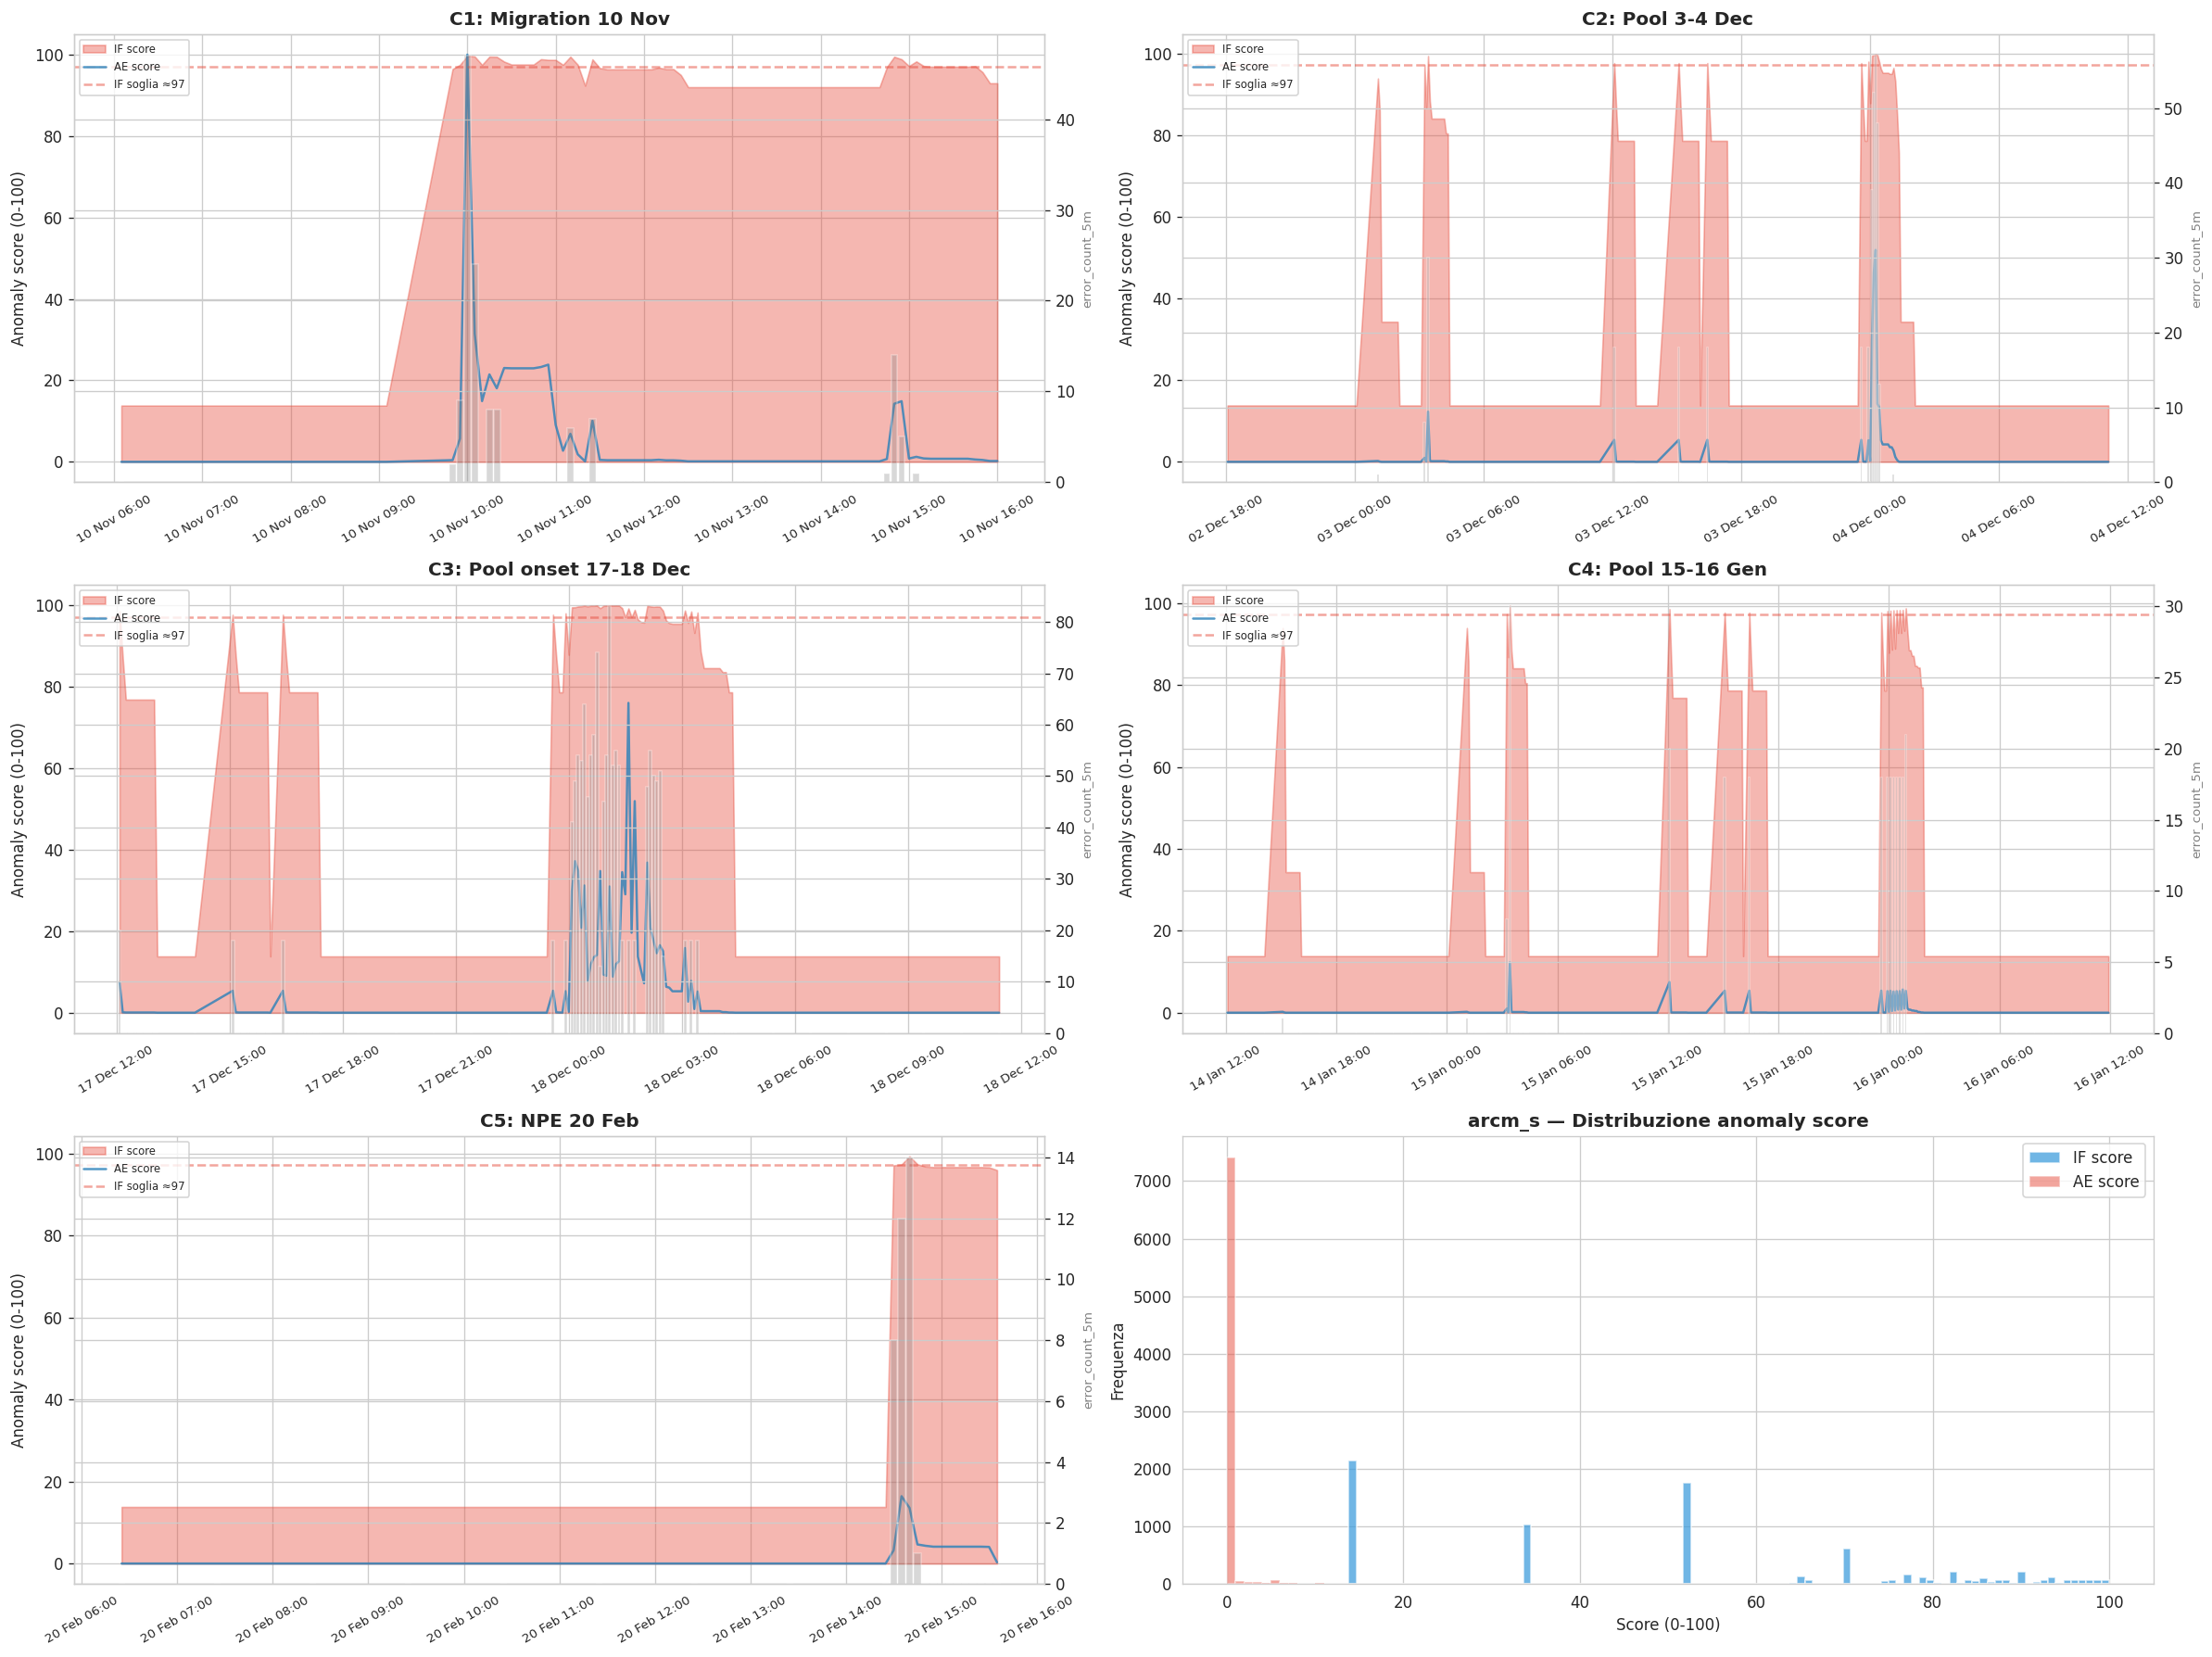

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

plot_windows = [
    ("C1: Migration 10 Nov", "2025-11-10 06:00", "2025-11-10 16:00"),
    ("C2: Pool 3-4 Dec", "2025-12-02 18:00", "2025-12-04 12:00"),
    ("C3: Pool onset 17-18 Dec", "2025-12-17 12:00", "2025-12-18 12:00"),
    ("C4: Pool 15-16 Gen", "2026-01-14 12:00", "2026-01-16 12:00"),
    ("C5: NPE 20 Feb", "2026-02-20 06:00", "2026-02-20 20:00"),
]

for i, (title, start, end) in enumerate(plot_windows):
    ax = axes[i]
    window = arcm[(arcm['ts'] >= start) & (arcm['ts'] <= end)].copy()
    
    if len(window) == 0:
        ax.text(0.5, 0.5, 'Nessun dato', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    
    # IF score
    ax.fill_between(window['ts'], window['if_score'], alpha=0.4, color='#e74c3c', label='IF score')
    
    # AE score (se disponibile)
    if 'ae_score' in window.columns and window['ae_score'].notna().any():
        ax.plot(window['ts'], window['ae_score'], '-', color='#2980b9', linewidth=1.5, 
                label='AE score', alpha=0.8)
    
    # Soglia IF (approssimata: score dove IF dice -1)
    if_thresh_mask = window['if_label'] == -1
    if if_thresh_mask.any():
        min_anom_score = window.loc[if_thresh_mask, 'if_score'].min()
        ax.axhline(min_anom_score, color='#e74c3c', linestyle='--', alpha=0.5, label=f'IF soglia ≈{min_anom_score:.0f}')
    
    # Error count (asse secondario)
    ax2 = ax.twinx()
    ax2.bar(window['ts'], window['error_count_5m'], width=0.003, alpha=0.3, color='gray', label='errors_5m')
    ax2.set_ylabel('error_count_5m', color='gray', fontsize=8)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Anomaly score (0-100)')
    ax.legend(loc='upper left', fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

# Ultimo subplot: distribuzione score IF globale arcm_s
ax = axes[5]
ax.hist(arcm['if_score'].dropna(), bins=100, color='#3498db', alpha=0.7, label='IF score')
if 'ae_score' in arcm.columns:
    ax.hist(arcm['ae_score'].dropna(), bins=100, color='#e74c3c', alpha=0.5, label='AE score')
ax.set_title('arcm_s — Distribuzione anomaly score', fontweight='bold')
ax.set_xlabel('Score (0-100)')
ax.set_ylabel('Frequenza')
ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Confronto Isolation Forest vs Autoencoder

In [10]:
print("CONFRONTO MODELLI — Tutti i runnable")
print("=" * 90)
print(f"{'Runnable':25s} | {'IF anomalie':>12s} | {'AE anomalie':>12s} | {'Accordo':>10s}")
print("-" * 90)

for runnable in sorted(df['runnable'].unique()):
    sub = df[df['runnable'] == runnable]
    
    if_a = (sub['if_label'] == -1).sum()
    if_pct = if_a / len(sub) * 100
    
    if 'ae_label' in sub.columns and sub['ae_label'].notna().any():
        ae_a = (sub['ae_label'] == -1).sum()
        ae_pct = ae_a / len(sub) * 100
        
        # Accordo: entrambi dicono anomalia
        both = ((sub['if_label'] == -1) & (sub['ae_label'] == -1)).sum()
        either = ((sub['if_label'] == -1) | (sub['ae_label'] == -1)).sum()
        jaccard = both / either * 100 if either > 0 else 0
        
        print(f"  {runnable:25s} | {if_a:>5d} ({if_pct:4.1f}%) | {ae_a:>5d} ({ae_pct:4.1f}%) | {jaccard:5.1f}% IoU")
    else:
        print(f"  {runnable:25s} | {if_a:>5d} ({if_pct:4.1f}%) | {'N/A':>12s} | {'N/A':>10s}")

CONFRONTO MODELLI — Tutti i runnable
Runnable                  |  IF anomalie |  AE anomalie |    Accordo
------------------------------------------------------------------------------------------
  abs_s                     |   141 ( 3.0%) |   141 ( 3.0%) |  53.3% IoU
  adsadmin_s                |   107 ( 2.9%) |   107 ( 2.9%) | 100.0% IoU
  agent                     |   875 ( 3.0%) |   875 ( 3.0%) |  51.3% IoU
  apg_s                     |   109 ( 3.0%) |   109 ( 3.0%) |  92.9% IoU
  arcm_s                    |   231 ( 3.0%) |   233 ( 3.0%) |  72.5% IoU
  cdf_s                     |    88 ( 2.6%) |    88 ( 2.6%) | 100.0% IoU
  ces_s                     |    93 ( 2.7%) |   100 ( 2.9%) |  70.8% IoU
  cloudsearch_s             |     6 ( 0.2%) |     6 ( 0.2%) | 100.0% IoU
  copernicus_s              |   128 ( 2.9%) |   133 ( 3.0%) |  81.2% IoU
  dashboarding_s            |   109 ( 2.9%) |    77 ( 2.1%) |  48.8% IoU
  ecp_s                     |    97 ( 2.5%) |    97 ( 2.5%) | 100.0% IoU


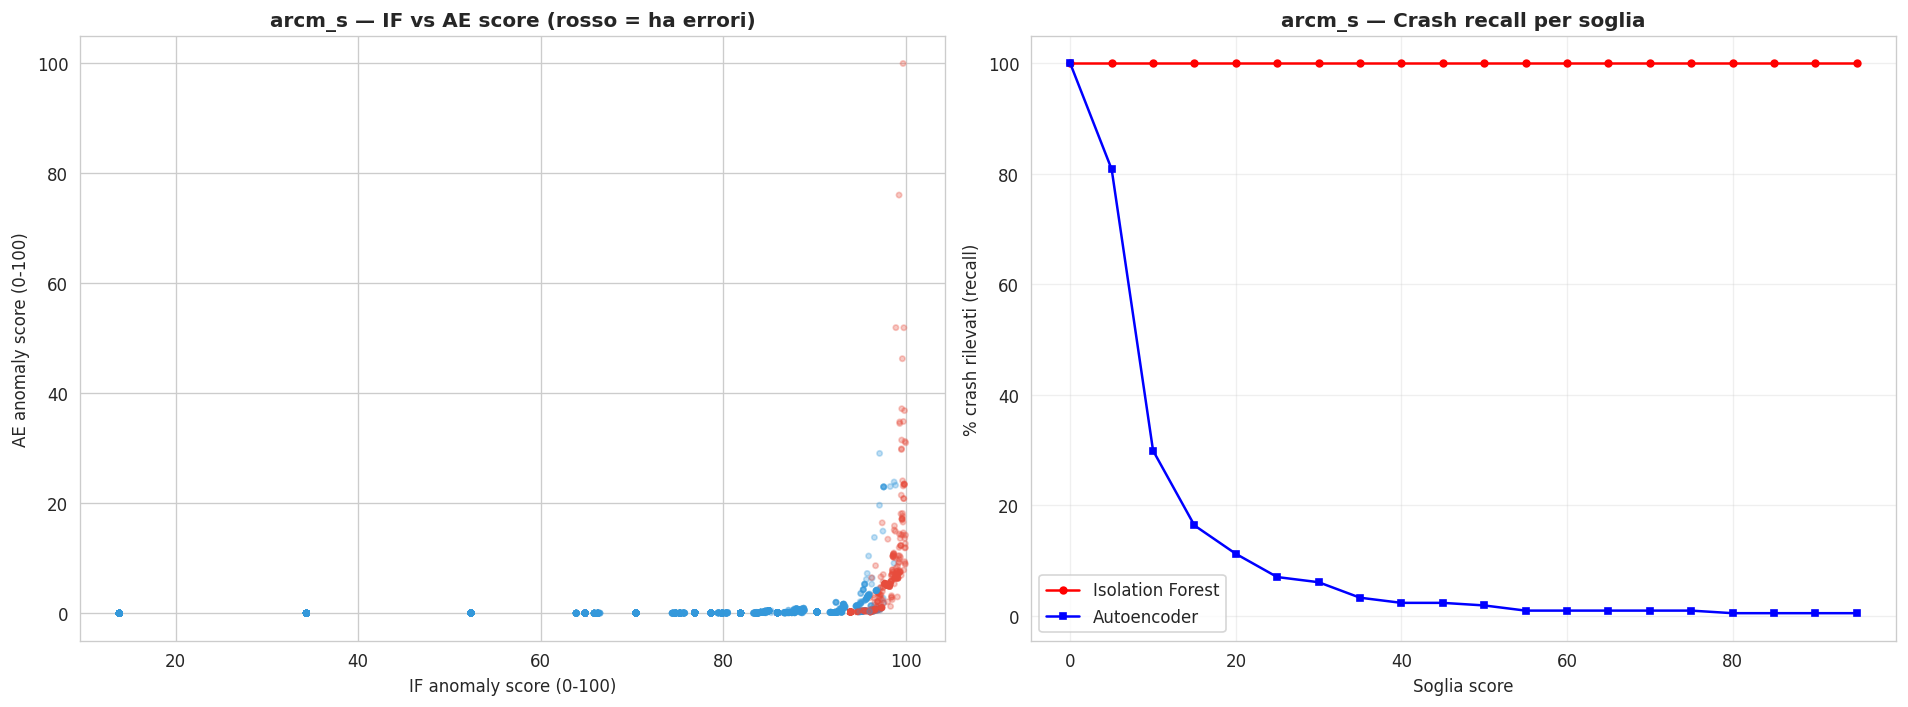

In [11]:
# Confronto visuale: scatter IF score vs AE score per arcm_s
if 'ae_score' in arcm.columns and arcm['ae_score'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    ax = axes[0]
    colors = ['#e74c3c' if e > 0 else '#3498db' for e in arcm['error_count_5m']]
    ax.scatter(arcm['if_score'], arcm['ae_score'], c=colors, alpha=0.3, s=10)
    ax.set_xlabel('IF anomaly score (0-100)')
    ax.set_ylabel('AE anomaly score (0-100)')
    ax.set_title('arcm_s — IF vs AE score (rosso = ha errori)', fontweight='bold')
    
    # ROC-like: quanti crash vengono catturati a ogni soglia
    ax = axes[1]
    thresholds = range(0, 100, 5)
    crash_vectors = arcm[arcm['error_count_5m'] > 5]  # vettori con errori significativi
    
    if_recall = [((crash_vectors['if_score'] >= t).sum() / len(crash_vectors) * 100) 
                 if len(crash_vectors) > 0 else 0 for t in thresholds]
    ae_recall = [((crash_vectors['ae_score'] >= t).sum() / len(crash_vectors) * 100) 
                 if len(crash_vectors) > 0 else 0 for t in thresholds]
    
    ax.plot(thresholds, if_recall, 'r-o', markersize=4, label='Isolation Forest')
    ax.plot(thresholds, ae_recall, 'b-s', markersize=4, label='Autoencoder')
    ax.set_xlabel('Soglia score')
    ax.set_ylabel('% crash rilevati (recall)')
    ax.set_title('arcm_s — Crash recall per soglia', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Autoencoder non disponibile — saltato il confronto visuale.")

---
## 6. Panoramica anomalie per tutti i runnable

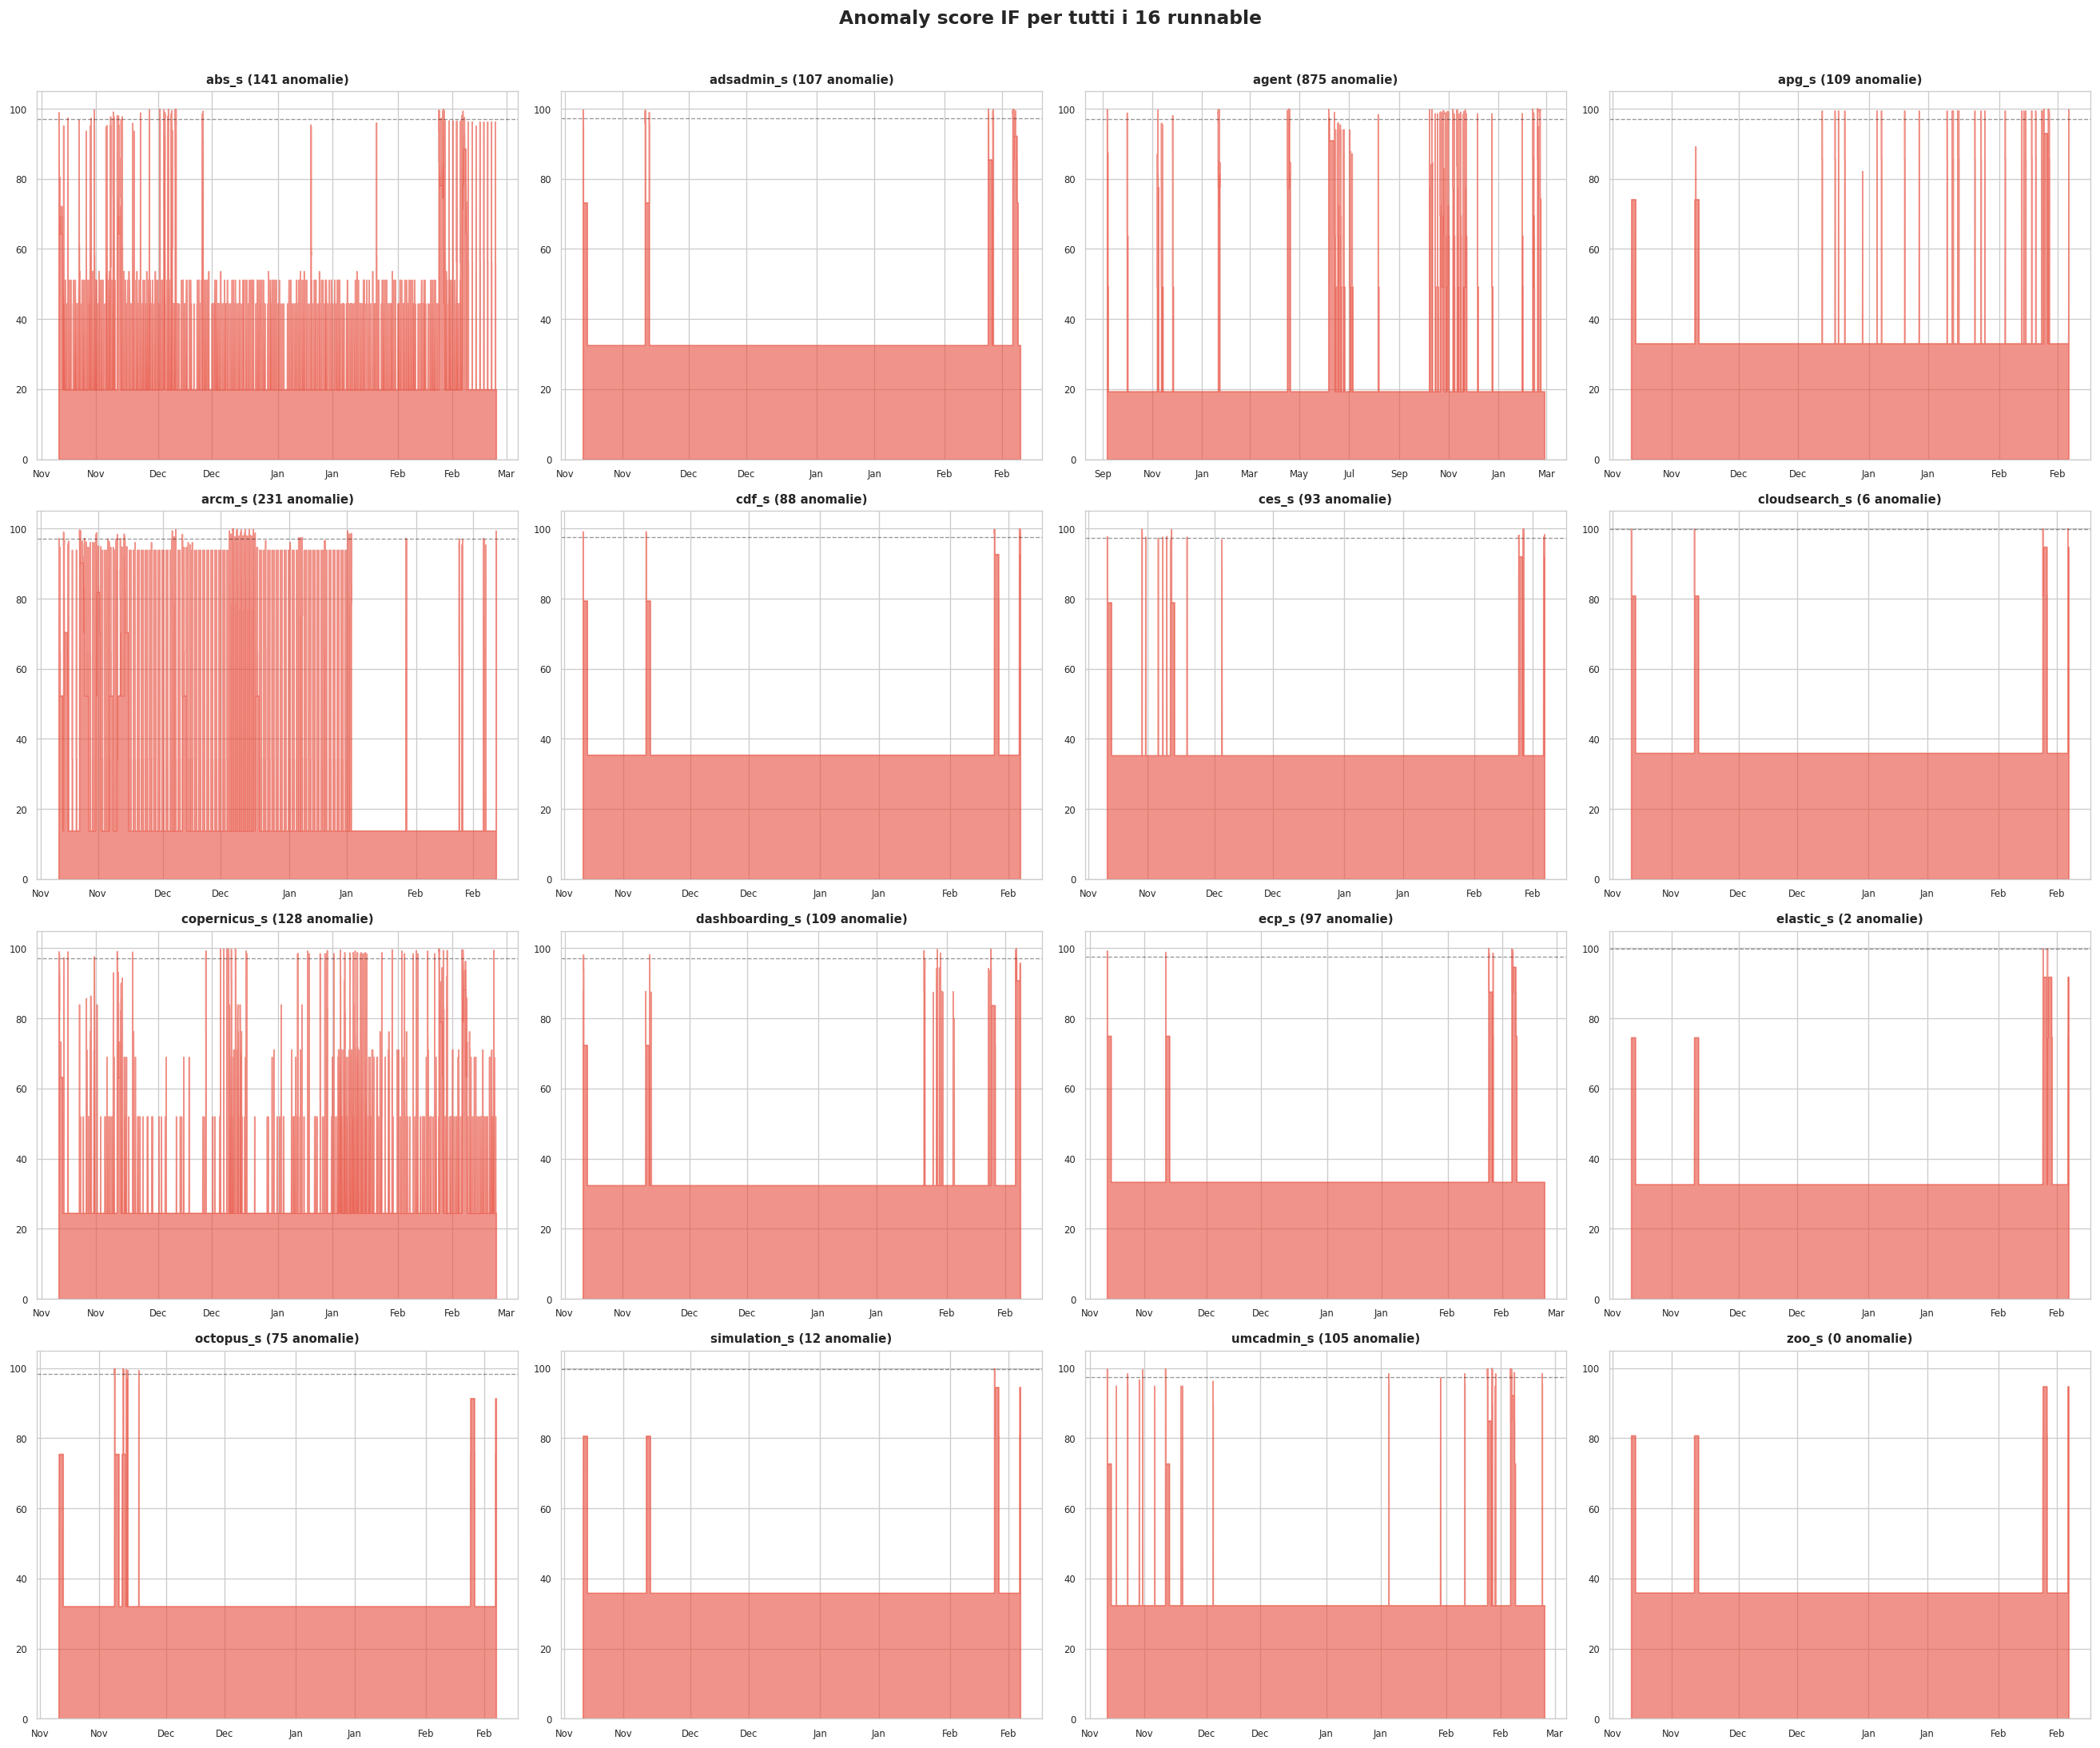

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

for i, runnable in enumerate(sorted(df['runnable'].unique())):
    ax = axes[i]
    sub = df[df['runnable'] == runnable].copy()
    
    # Timeline IF score
    ax.fill_between(sub['ts'], sub['if_score'], alpha=0.6, color='#e74c3c')
    
    # Soglia
    if_thresh_mask = sub['if_label'] == -1
    if if_thresh_mask.any():
        min_anom = sub.loc[if_thresh_mask, 'if_score'].min()
        ax.axhline(min_anom, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
    
    n_anom = if_thresh_mask.sum()
    ax.set_title(f"{runnable} ({n_anom} anomalie)", fontweight='bold', fontsize=9)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Anomaly score IF per tutti i 16 runnable', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Salvataggio modelli e risultati

In [13]:
import os

# Crea directory per i modelli
os.makedirs("../models", exist_ok=True)

# Salva IF models + scalers
for runnable in if_models:
    with open(f"../models/if_{runnable}.pkl", "wb") as f:
        pickle.dump({
            'model': if_models[runnable],
            'scaler': if_scalers[runnable],
            'feature_cols': FEATURE_COLS,
            'contamination': IF_CONTAMINATION,
            'n_estimators': IF_N_ESTIMATORS,
        }, f)

# Salva il dataframe con gli score
df.to_csv("../features_scored.csv", index=False)

print(f"Modelli IF salvati in ../models/ ({len(if_models)} file)")
print(f"Dataset con score salvato in ../features_scored.csv")
print(f"\nPer caricare un modello:")
print(f"  with open('models/if_arcm_s.pkl', 'rb') as f:")
print(f"      data = pickle.load(f)")
print(f"  model = data['model']")
print(f"  scaler = data['scaler']")

Modelli IF salvati in ../models/ (16 file)
Dataset con score salvato in ../features_scored.csv

Per caricare un modello:
  with open('models/if_arcm_s.pkl', 'rb') as f:
      data = pickle.load(f)
  model = data['model']
  scaler = data['scaler']


---
## 8. Riepilogo e prossimi passi

### Risultati da discutere:
1. Quanti crash su 5 sono stati rilevati dall'IF? E dall'AE?
2. C'è stato early warning (allarme prima del crash)?
3. Quale modello ha recall migliore?
4. Ci sono falsi positivi evidenti (anomalie segnalate in periodi calmi)?

### Prossimi passi:
- **Integrare i CSV monitordata** (lacuna #7) → feature infrastrutturali reali
- **Tuning soglie** → adattare contamination/threshold per runnable
- **Feature sintetiche** → error_velocity, time_in_non_started_state, is_business_hours
- **Dashboard B7** → visualizzazione real-time degli score
- **Documentazione per bando BIP** → risultati, architettura, roadmap